In [3]:
%pip install langgraph

  Using cached langgraph_checkpoint-4.2.0-py3-none-any.whl.metadata (6.7 kB)
  Using cached langgraph_prebuilt-1.1.0-py3-none-any.whl.metadata (5.2 kB)
  Using cached pydantic-2.13.5-py3-none-any.whl.metadata (110 kB)
  Using cached xxhash-4.0.1-cp314-cp314-macosx_10_15_x86_64.whl.metadata (17 kB)
  Using cached jsonpatch-1.33-py2.py3-none-any.whl.metadata (3.0 kB)
  Using cached langchain_protocol-0.0.19-py3-none-any.whl.metadata (2.4 kB)
  Using cached uuid_utils-0.17.1-cp314-cp314-macosx_10_12_x86_64.whl.metadata (6.4 kB)
  Using cached ormsgpack-1.12.2-cp314-cp314-macosx_10_12_x86_64.macosx_11_0_arm64.macosx_10_12_universal2.whl.metadata (3.2 kB)
  Using cached orjson-3.12.0-cp314-cp314-macosx_10_15_x86_64.macosx_11_0_arm64.macosx_10_15_universal2.whl.metadata (41 kB)
  Using cached distro-1.9.0-py3-none-any.whl.metadata (6.8 kB)
  Using cached requests_toolbelt-1.0.0-py2.py3-none-any.whl.metadata (14 kB)
  Using cached zstandard-0.25.0-cp314-cp314-macosx_10_13_x86_64.whl.metadata 

In [1]:
import langgraph
print("LangGraph installed successfully!")

LangGraph installed successfully!


In [4]:
%pip install -U langchain-google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 880.4/880.4 kB 12.7 MB/s  0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.5 MB/s  0:00:00
  Created wheel for cryptography: filename=cryptography-50.0.1-cp314-abi3-macosx_10_12_x86_64.whl size=1989989 sha256=32a8e08837c8bf6719731867a110a84e24ea4c016907c2d2ad4c436000aad5fd
  Stored in directory: /Users/aliakbar/Library/Caches/pip/wheels/91/02/93/0d3c95b5578dfc47814be1c2dd4e08602724284dd2611f5b5e
Successfully built cryptography
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [langchain-google-genai]5/7 [google-genai]

[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
%pip install dotenv

  Using cached python_dotenv-1.2.3-py3-none-any.whl.metadata (29 kB)
Using cached python_dotenv-1.2.3-py3-none-any.whl (22 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [dotenv]

[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [28]:
from langgraph.graph import StateGraph, START, END
from typing import Annotated
from typing_extensions import TypedDict
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from langgraph.checkpoint.memory import MemorySaver

In [7]:
load_dotenv()

True

In [20]:
llm = ChatGoogleGenerativeAI(
    model="gemini-3.8-flash",
    google_api_key="AQ.Ab8RN6LKGMopEBbJsApCbQ7vJsUhGRh8t7qVq-oVbywXiE--wQ"
)

In [14]:
from langgraph.graph.message import add_messages
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [15]:
def chat_node(state: ChatState):
    #take user query from state
    messages = state['messages']
    # send to llm
    response = llm.invoke(messages)
    # response store state
    return {'messages' : [response]}

In [29]:
checkpoint = MemorySaver()

graph = StateGraph(ChatState)

#add nodes
graph.add_node('chat_node', chat_node)

# add edges
graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile(checkpointer = checkpoint)

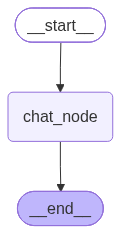

In [30]:
chatbot

In [31]:
initial_state = {
    'messages' : [HumanMessage(content='What is Object oriented  in python?')]
}

response = chatbot.invoke(initial_state)

ValueError: Checkpointer requires one or more of the following 'configurable' keys: thread_id, checkpoint_ns, checkpoint_id

In [ ]:
thread_id = "1"

while True:
    user_message = input('Type here: ')
    
    print('User:' , user_message)

    if user_message.strip().lower() in ['exit', 'quit', 'bye']:
                         break
    config = {'configurable': {'thread_id': thread_id}}
    response = chatbot.invoke({'messages' : [HumanMessage(content=user_message)]}, config= config)
    print("Bot:", response["messages"][-1].content)

Type here:  hi, my name is ali


User: hi, my name is ali
Bot: [{'type': 'text', 'text': 'Hello Ali! Nice to meet you. How can I help you today?', 'extras': {'signature': 'EqIFCp8FAWkUfRM5ptxCveT9bTvv30FeQnsjzCWHV6DfXHTTVsZIinixfofAeRF32ZffqYkY8ZqxzE+PlqpVJ1gsKr37GnPbONQZBnO8yodYtPOG9ElpHC5dvRzN+318hVnK+/Q1iAILUzB+5+mwLpDIkxYCXixuKcDSMdQk5JT0qIK23G1KmCl3oFGfsqE6Rua+Piy96TS/33s3cqA8QKcSkQlYypOgDBD/brz0qM1VrjQF6pYRh98P9iWQIkO68Y+JbOauSY05Ufb49E23+hQ7UD89R21TZ5kmnrYV4F9edNPp6djPBrLLJHqfjwb49g/Bq+WxeViKKQiRAz8I63lZT7+Sps+UJIz2S052aeJxItHTILIpIkEf71KC4Kj2Sx+CM30wr8PEPYTBedP4gASjw1iuFtJsj29fLIubQVXTNdCQ5YmaGyPSOhGi9RqfUuRJGbJYlH8iViHackQEyrZVAzOu7cRaH6a4vjmTKiWKkXfES5O6lwVWytsuIWhmnyTYm64rqUmXi2LNiZOM9MRDBgN3upOGCaRY0ALY3gfMnjlNjPZB5bPPRfePb9HMpfzm0ZqG4TiVnkf446tfqYS7PrF7nMwg/L8xKkUV0AQybNQhMFc8h3uqBKja+pMR85BS3tSTGuNGdzv0NTZtKmPdxIxCCy2Z29Dh5DEKAzH3qVwlbY9ZRo13aZ56apTvjWoo4OULhL9UQ92XMKpsXnmGoNxxHO7FBBBRv1JUh86mvvBKV3GY3cgFQhwbR0MnzY21Umw0Cg9wXWUhy5tIE6XUCQWrNdYLKLN7LYhuytQ0aQA1d2NrHUv49TPbWASiGjJX3xhyhBIrSQKlrW5cKhEQW54y0

Type here:  what is python


User: what is python
Bot: [{'type': 'text', 'text': '**Python** is a popular, high-level, and easy-to-learn programming language. It was created by Guido van Rossum and first released in 1991.\n\nHere is a breakdown of what makes it special and what it is used for:\n\n---\n\n### 1. Why is Python so popular?\n* **Easy to Read and Write:** Python’s syntax is clean and looks very similar to plain English. This makes it beginner-friendly.\n* **Interpreted:** You don\'t need to compile Python code before running it. It runs line-by-line, which makes testing and debugging fast.\n* **Versatile (Multi-purpose):** You can use it for building websites, analyzing data, automating repetitive tasks, creating games, and much more.\n* **Huge Community & Libraries:** Python has thousands of free, pre-built packages (called libraries) that allow you to do complex tasks with just a few lines of code.\n\n---\n\n### 2. What is it used for?\n* **Data Science & AI:** It is the #1 language for Artificial Int

Type here:  what is my name?


User: what is my name?
Bot: [{'type': 'text', 'text': 'Your name is **Ali**!', 'extras': {'signature': 'EpYDCpMDAWkUfRP7gvhqS44CkKSptgBaTirLEpzXdV4MtBsWxf1DEJdX/PROusur+z4GBxLQE/5tPqCcG4Peafn4KkgH9czSdqbmTWi5R15Bo95DBt/cp2UWxWNQKZ7VWy8wPefEMyBI35Gdgbxggh95Q4a7iY1unhccODorc7Ygglw3RnJeN7KYH6u/QoNW5oHkIBZNUoTCCbcmBfYget8sxN5sNk3M3BqUbWwimiNHmicIETVSzaptp3ramCmDw3Nl/SYMRVje43RSw9acgtgsWr3b/6TYYuUe2p8Gmu+TnVcqqg4HLXibuoOFIoZ8WxwRPMnxM714R9Kpc+j8VkPMhnzcEJdEh6Tb3n2iLtTxSUnAtvAO5z0UmekXWZJ0iF31pzurO2kNanYgWBmmVTOZJaeUhp9OvYifi7Lq5BaTutAxLkdkC4GTXgHjrUgTWDmgYV7tZoOLM7UcjqCYU2hTTLKF1MWBl9YKq305c6C9AI4TlCpMNCULVjCxTwCMcBg9JIIbAks0uXQweO56sy4NZvo2H/kJpQ=='}}]
